# Simple Linear Regression - شرح ثنائي اللغة / Bilingual Walkthrough

هذا الدفتر مرتب خطوة بخطوة لشرح **الانحدار الخطي البسيط**.
This notebook is organized step-by-step to explain **Simple Linear Regression**.

## الترتيب / Flow
1. استيراد المكتبات - Import libraries
2. قراءة البيانات واستكشافها - Load and inspect data
3. تجهيز `X` و `y` - Prepare features and target
4. تقسيم البيانات - Train/Test split
5. القياس (اختياري) - Feature scaling (optional)
6. تدريب النموذج - Train model
7. التنبؤ - Predict
8. الرسم - Visualization
9. تفسير المعاملات والإحصائيات - Coefficients and statistical summary

In [ ]:
# Step 1) استيراد المكتبات / Import libraries
# numpy: للعمليات العددية - numerical operations
# matplotlib: للرسم البياني - plotting
# pandas: للتعامل مع البيانات الجدولية - tabular data handling
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Step 2) قراءة البيانات / Load dataset
# نقرأ ملف الرواتب الذي يحتوي سنوات الخبرة والراتب
# Read salary dataset containing YearsExperience and Salary
dataset = pd.read_csv('Salary_Data.csv')

In [ ]:
# عرض البيانات كاملة لمراجعة الشكل العام
# Display full dataset for quick inspection
dataset

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


from matplotlib import pyplot as plt
dataset['YearsExperience'].plot(kind='hist', bins=20, title='YearsExperience')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
dataset['Salary'].plot(kind='hist', bins=20, title='Salary')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
dataset.plot(kind='scatter', x='YearsExperience', y='Salary', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['YearsExperience']
  ys = series['Salary']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = dataset.sort_values('YearsExperience', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('YearsExperience')
_ = plt.ylabel('Salary')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['YearsExperience']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'YearsExperience'}, axis=1)
              .sort_values('YearsExperience', ascending=True))
  xs = counted['YearsExperience']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = dataset.sort_values('YearsExperience', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('YearsExperience')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
dataset['YearsExperience'].plot(kind='line', figsize=(8, 4), title='YearsExperience')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
dataset['Salary'].plot(kind='line', figsize=(8, 4), title='Salary')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
# Step 3) تجهيز المتغيرات / Prepare variables
# X = المتغير المستقل (سنوات الخبرة) - independent variable
# y = المتغير التابع (الراتب) - dependent variable
X = dataset.iloc[:, :-1].values

In [ ]:
X

array([[ 1.1],
       [ 1.3],
       [ 1.5],
       [ 2. ],
       [ 2.2],
       [ 2.9],
       [ 3. ],
       [ 3.2],
       [ 3.2],
       [ 3.7],
       [ 3.9],
       [ 4. ],
       [ 4. ],
       [ 4.1],
       [ 4.5],
       [ 4.9],
       [ 5.1],
       [ 5.3],
       [ 5.9],
       [ 6. ],
       [ 6.8],
       [ 7.1],
       [ 7.9],
       [ 8.2],
       [ 8.7],
       [ 9. ],
       [ 9.5],
       [ 9.6],
       [10.3],
       [10.5]])

In [ ]:
# y الهدف الذي نريد توقعه (الراتب)
# y is the target variable we want to predict (Salary)
y = dataset.iloc[:, 1:2].values

In [ ]:
y

array([[ 39343.],
       [ 46205.],
       [ 37731.],
       [ 43525.],
       [ 39891.],
       [ 56642.],
       [ 60150.],
       [ 54445.],
       [ 64445.],
       [ 57189.],
       [ 63218.],
       [ 55794.],
       [ 56957.],
       [ 57081.],
       [ 61111.],
       [ 67938.],
       [ 66029.],
       [ 83088.],
       [ 81363.],
       [ 93940.],
       [ 91738.],
       [ 98273.],
       [101302.],
       [113812.],
       [109431.],
       [105582.],
       [116969.],
       [112635.],
       [122391.],
       [121872.]])

In [ ]:
# Step 4) تقسيم البيانات / Train-Test Split
# نقسم البيانات: 67% تدريب و 33% اختبار
# Split data into training (67%) and testing (33%)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=0)

In [ ]:
X_train.shape

(20, 1)

In [ ]:
y_train.shape

(20, 1)

In [ ]:
X_test.shape

(10, 1)

In [ ]:
# Step 5) القياس / Feature Scaling (اختياري في الانحدار الخطي البسيط)
# ملاحظة: غالبا SLR يعمل بدون scaling، لكن هنا نطبقه للتجربة التعليمية
# Note: SLR often works without scaling, but we apply it here for learning
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## بديل اختياري / Optional Alternative
يمكن استخدام **MinMaxScaler** بدل StandardScaler حسب طبيعة البيانات.
You can use **MinMaxScaler** instead of StandardScaler depending on data characteristics.

```python
from sklearn.preprocessing import MinMaxScaler
normalizer = MinMaxScaler()

X_train = normalizer.fit_transform(X_train)
X_test = normalizer.transform(X_test)
```

In [ ]:
X_train

In [ ]:
# Step 6) تدريب النموذج / Train the model
# ننشئ نموذج الانحدار الخطي ثم ندرّبه على بيانات التدريب
# Create linear regression model and fit it on training data
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Step 7) التنبؤ / Prediction
# نتوقع الرواتب في مجموعة الاختبار
# Predict salaries for test set
y_pred = regressor.predict(X_test)

In [ ]:
y_pred

array([[ 40835.10590871],
       [123079.39940819],
       [ 65134.55626083],
       [ 63265.36777221],
       [115602.64545369],
       [108125.8914992 ],
       [116537.23969801],
       [ 64199.96201652],
       [ 76349.68719258],
       [100649.1375447 ]])

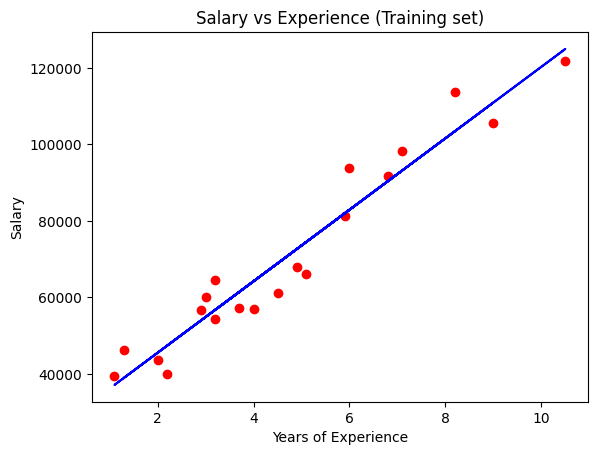

In [ ]:
# Step 8) الرسم - بيانات التدريب / Visualization - Training set
# النقاط الحمراء: القيم الحقيقية - Red dots: actual values
# الخط الأزرق: خط الانحدار - Blue line: regression line
plt.scatter(X_train, y_train, color='red')
plt.plot(X_train, regressor.predict(X_train), color='blue')
plt.title('Salary vs Experience (Training set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

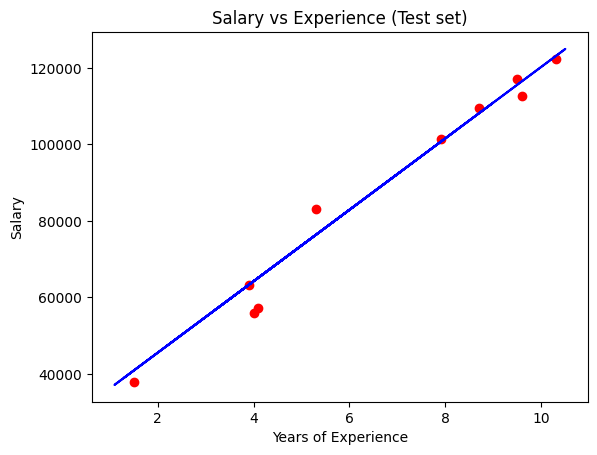

In [ ]:
# Step 8) الرسم - بيانات الاختبار / Visualization - Test set
# نستخدم نفس خط التدريب للمقارنة مع نقاط الاختبار
# Use the same training regression line to compare with test points
plt.scatter(X_test, y_test, color='red')
plt.plot(X_train, regressor.predict(X_train), color='blue')
plt.title('Salary vs Experience (Test set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

In [ ]:
# Step 9) تفسير النموذج / Model interpretation
# في الخلايا القادمة سنعرض المعاملات والملخص الإحصائي
# Next cells print coefficients and full statistical summary

In [ ]:
# المعاملات / Coefficients
# coefficient: مقدار تغير الراتب عند زيادة سنة خبرة واحدة
# intercept: الراتب المتوقع عندما تكون الخبرة = 0
coefficients = regressor.coef_
intercept = regressor.intercept_

print("Coefficients:", coefficients)
print("Intercept:", intercept)

Coefficients: [[9345.94244312]]
Intercept: [26816.19224403]


In [ ]:
import statsmodels.api as sm

# التحقق الإحصائي / Statistical validation
# نضيف ثابتا (constant) حتى يحسب النموذج قيمة الـ intercept
# Add constant term so OLS estimates intercept properly
X_train_with_constant = sm.add_constant(X_train)

# نبني نموذج OLS للحصول على p-value و R-squared وتفاصيل إضافية
# Fit OLS to get p-values, R-squared, and full diagnostics
model = sm.OLS(y_train, X_train_with_constant)
results = model.fit()

# عرض الملخص الإحصائي الكامل / Print full statistical summary
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     273.2
Date:                Mon, 27 Oct 2025   Prob (F-statistic):           2.51e-12
Time:                        08:00:53   Log-Likelihood:                -202.60
No. Observations:                  20   AIC:                             409.2
Df Residuals:                      18   BIC:                             411.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.682e+04   3033.148      8.841      0.0

In [ ]:
# Step 10) تقييم النموذج / Model Evaluation Metrics
# MAE: متوسط الخطأ المطلق - average absolute error
# MSE: متوسط مربع الخطأ - average squared error
# RMSE: الجذر التربيعي لـ MSE (بوحدة الراتب) - error in salary units
# R2: نسبة التفسير - explained variance ratio
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.2f}")
print(f"MSE  = {mse:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R2   = {r2:.4f}")